In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

file_path = r"C:/Users/Kanouj Bose/Downloads/archive (1)/insurance.csv"
df = pd.read_csv(file_path)

In [2]:
print("Task 1: Data Understanding")

print("First 5 records of the dataset:")
print(df.head())

print("Dataset Info:")
df.info()

Task 1: Data Understanding
First 5 records of the dataset:
   age     sex     bmi  children smoker     region      charges
0   19  female  27.900         0    yes  southwest  16884.92400
1   18    male  33.770         1     no  southeast   1725.55230
2   28    male  33.000         3     no  southeast   4449.46200
3   33    male  22.705         0     no  northwest  21984.47061
4   32    male  28.880         0     no  northwest   3866.85520
Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [3]:
print("Task 2: Data Preprocessing")
missing_values = df.isnull().sum()
print("Missing values per column:")
print(missing_values)

df_encoded = pd.get_dummies(df, columns=['sex', 'smoker', 'region'], drop_first=True)
print("Encoded Dataset Sample:")
print(df_encoded.head())

X = df_encoded.drop(columns=['charges'])
y = df_encoded['charges']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Training set size: {X_train.shape[0]} samples")
print(f"Testing set size: {X_test.shape[0]} samples")

Task 2: Data Preprocessing
Missing values per column:
age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64
Encoded Dataset Sample:
   age     bmi  children      charges  sex_male  smoker_yes  region_northwest  \
0   19  27.900         0  16884.92400     False        True             False   
1   18  33.770         1   1725.55230      True       False             False   
2   28  33.000         3   4449.46200      True       False             False   
3   33  22.705         0  21984.47061      True       False              True   
4   32  28.880         0   3866.85520      True       False              True   

   region_southeast  region_southwest  
0             False              True  
1              True             False  
2              True             False  
3             False             False  
4             False             False  
Training set size: 1070 samples
Testing set size: 268 samples


In [4]:
print("Task 3: Model Development")

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
print("Model training complete. Predictions generated for the test set.")

Task 3: Model Development
Model training complete. Predictions generated for the test set.


Task 4: Model Evaluation
Mean Absolute Error (MAE): $4181.19
Mean Squared Error (MSE): 33596915.85
Root Mean Squared Error (RMSE): $5796.28
R2 Score: 0.7836
Scatter plot saved as 'actual_vs_predicted.png'.


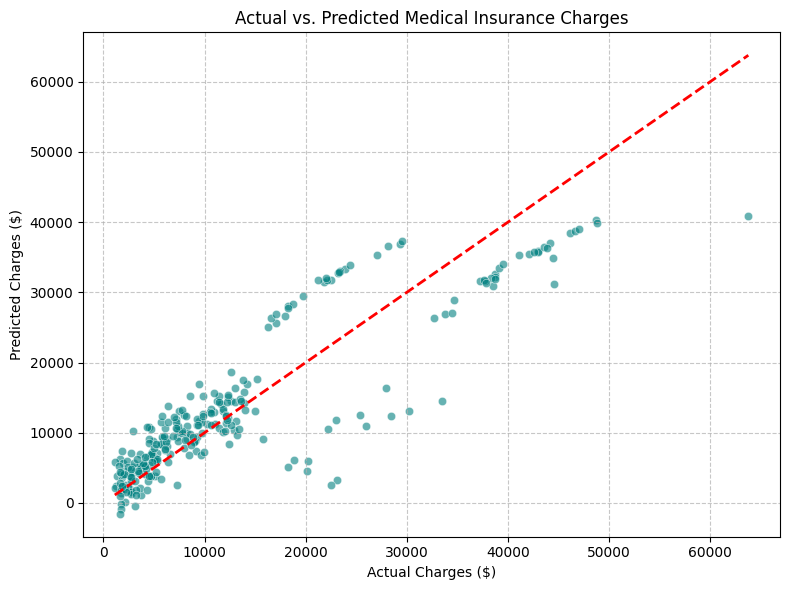

In [5]:
print("Task 4: Model Evaluation")

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"Mean Absolute Error (MAE): ${mae:.2f}")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Root Mean Squared Error (RMSE): ${rmse:.2f}")
print(f"R2 Score: {r2:.4f}")

plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.6, color='teal')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2) # Identity line
plt.title('Actual vs. Predicted Medical Insurance Charges')
plt.xlabel('Actual Charges ($)')
plt.ylabel('Predicted Charges ($)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()

plt.savefig('actual_vs_predicted.png')
print("Scatter plot saved as 'actual_vs_predicted.png'.")
plt.show()